In [1]:
import matplotlib.pyplot as plt
import numpy as np

## ERICCa Tutorial

This tutorial will show you how to

- Calculate eikonal phases 
- Calculate a reaction cross section using the matter densities as inputs
- Calculate a reaction cross section using the profile function densities as inputs

Before we start, we need to load ERICCa into our Jupyter environment.

In [2]:
import ERICCA as ERICCa

### Calculate the Glauber model reaction cross section: Matter densities

ERICCa calculates reaction cross sections in the Glauber scattering theory. We need the matter densities of the target and projectile as inputs to calculate a reaction cross section, So first we load in our densities into our environment. In this example, we will be calculating a $^{12}$ C on $^{12}$ C reaction cross section. I am loading in $^{12}$ C matter densities calculated using the 14D Fayans energy density functions. The C is the density and as a function of radius r, where C_r_mesh is our corresponding r

In [24]:
#Loading the densites
C = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-mass.txt", unpack= True) 
C_r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt", unpack= True)

print(C.shape)
print(C_r_mesh.shape)

(500, 31)
(500, 31)


The array C and C_r_mesh are 500 sample sets of C densities in the files 12Crho-mass.txt and 12C_radius.txt. For our calculation, we only need one set. Graphed the $^{12}$ C sample looks like the following:

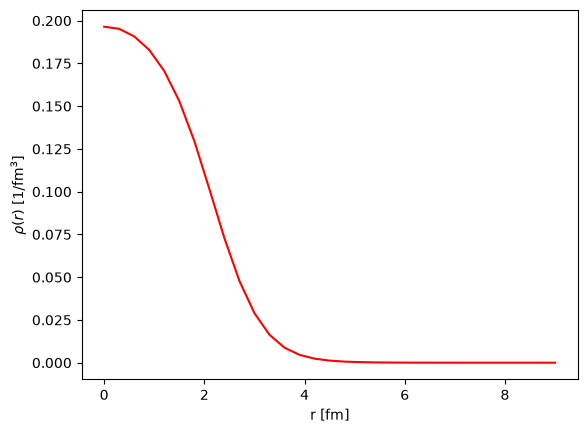

In [25]:
plt.plot(C_r_mesh[0], C[0], color = "r" )
plt.ylabel(r"$\rho(r)$ [1/fm$^3$]")
plt.xlabel(r"r [fm]")
plt.show()

If you don't have a matter density you can always approximate a density using ERICCa.Density to create a density of your own. 

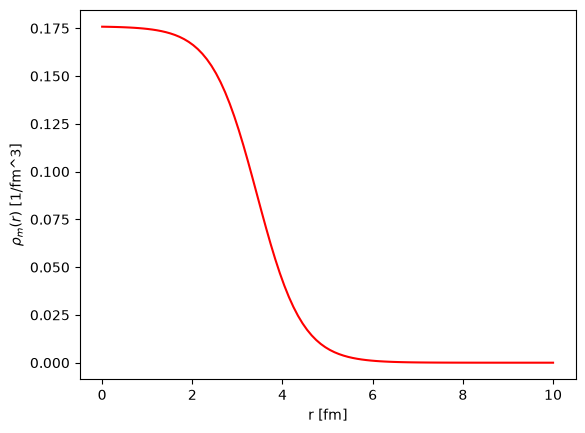

In [26]:
#you can generate a density by calling the density class in ERICCa

my_12C_rho = ERICCa.Density ()

#ERICCa.Density has a default mass density in the shape of a two point fermi function where you can input the terms directly
#I chose generally accepted values for the matter raidus of a two point fermi function.

my_12C_rho.C_m_p = 1.5 * (12)**(1/3)  # half-density radius
my_12C_rho.a_m_p = .5 # diffuseness [fm]
my_12C_rho.rho_0_p = .176 # the saturation density [fm^-3]

#the resulting rms radius
r_mesh = np.linspace(.001, 10, 100)

plt.plot(r_mesh,my_12C_rho.rho_m(r_mesh), color ="r")
plt.ylabel(r"$\rho_m(r)$ [1/fm^3]")
plt.xlabel("r [fm]")
plt.show()

If you also have no intuition on the density of an isotope you can call Density.rho_m_2pt_fermi(). 

    Density.rho_m_2pt_fermi(A, rms_measured, ra =0, rb=30 , r_points = 1000)

This function fits a two point fermi function $\rho_m(r) = \frac{\rho_0}{1 + \exp{(r-C_m)/a_m}}$ based off of  mass number A, and the rms_measured, measured matter radius of a nuclei in fm. The rms radius is calculated using an integral you can adjust the bounds of the integral using the ra, rb, r_points. The default settings are shown.

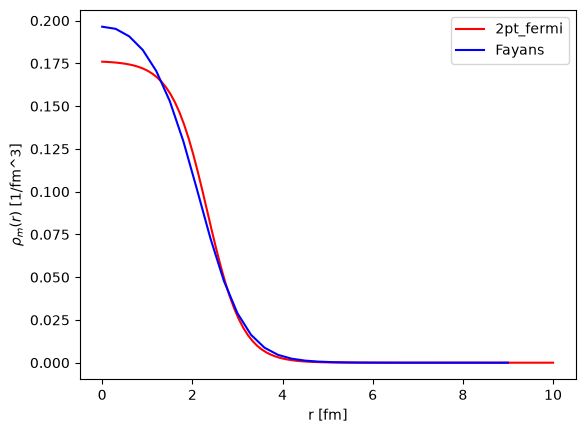

C_m: 2.334
a_m: 0.391
rho_0: 0.176


In [27]:
#you can generate a density by calling ERICCa density

my_12C_rho = ERICCa.Density ()

#You generate a fitted fermi density by using rho_m_2pt_fermi()
A_12C = 12 #Mass number of carbon 
rms_12C = 2.32 #rms radius of C12

my_12C_rho.rho_m_2pt_fermi(A_12C,rms_12C)

#To call the the fitted density use .rho_m() 

#We can compare to fitted two point fermi density to the density generated by the fayans

plt.plot(r_mesh,my_12C_rho.rho_m(r_mesh), color ="r", label = "2pt_fermi")
plt.plot(C_r_mesh[0], C[0], color = "b", label = "Fayans" )
plt.ylabel(r"$\rho_m(r)$ [1/fm^3]")
plt.xlabel("r [fm]")
plt.legend()
plt.show()

#you can also get the parameters of the fitted density by calling the attributes of the density class

print("C_m:" , np.round(my_12C_rho.C_m_p, 3))
print("a_m:" , np.round(my_12C_rho.a_m_p,3))
print("rho_0:" ,np.round(my_12C_rho.rho_0_p,3))

 ERICCa density can also calculate the rms radius of a density by calling density.rms(). 

    density.rms(r_mesh ,rho_mesh , A)

Where the input parameters are r_mesh is radial mesh in [fm], rho_m_mesh is the matter density of a nucleus as a function of radius [1/fm^3], and A as the mass number. The only stipulation is that r_mesh and rho_m_mesh should be the same size.

In [28]:
print(np.round(my_12C_rho.rms(C_r_mesh[0], C[0],12),3))
print(np.round(my_12C_rho.rms(r_mesh,my_12C_rho.rho_m(r_mesh),12),3))

2.417
2.32


The second ingredient needed for a reaction cross section calculation in the Glauber model is the profile function. The profile function is the effective interaction between the target and projectile nucleus. This can be called using the class ProfileFunction in ERICCa

    ERICCa.ProfileFunction(model_type = "general", E = 100)

There are two input parameters in ProfileFunction: model_type, which indicates the type of reaction [ "general", "np", "matter"], and E, which indicates the energy of reaction in MeV. The default parameters for model_type = "general" and E = 100. If you already have parameters for the profile function, you can keep the default settings and input profile function parameters as follows. 


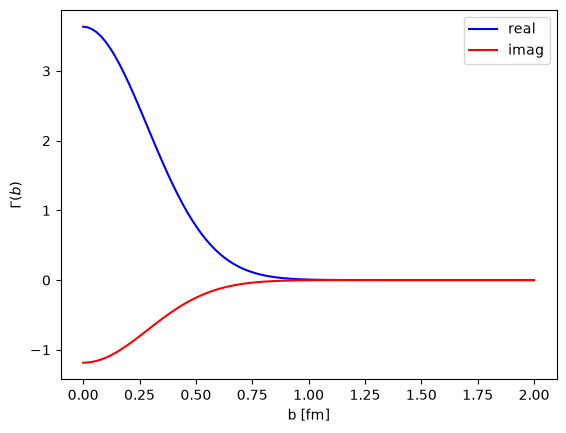

In [29]:
#An example of a programed example of a profile function
profile_funct= ERICCa.ProfileFunction()
profile_funct.alpha = 0.326
profile_funct.beta = 0.081 # fm^2
profile_funct.sigma_n = 3.7 #fm^2

#You can call your profile function with profile_funct.Gamma(b) where b is the impact parameter mesh
b_mesh = np.linspace(0, 2, 100)
plt.plot(b_mesh, profile_funct.Gamma(b_mesh).real, color = "b", label = "real")
plt.plot(b_mesh, profile_funct.Gamma(b_mesh).imag, color = "r", label = "imag")
plt.xlabel("b [fm]")
plt.ylabel(r"$\Gamma(b)$")
plt.legend()
plt.show()


If you don't have profile function parameters in mind, you can simply set model_type = "matter" and set E to the energy of the reaction, and a profile function will be generated.

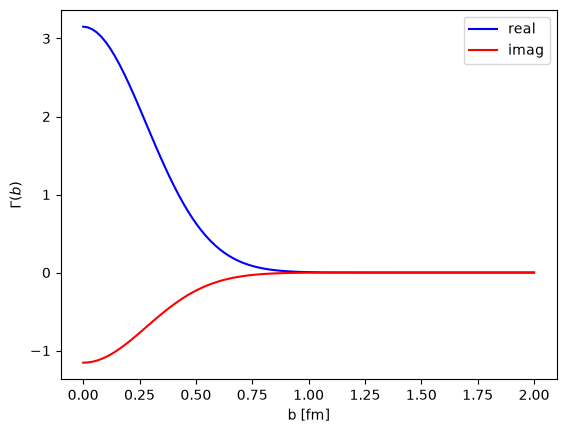

In [30]:
#An example of a programed example of a profile function
profile_funct_preset= ERICCa.ProfileFunction(model_type = "matter", E = 300)

#You can call your profile function with profile_funct.Gamma(b) where b is the impact parameter mesh
b_mesh = np.linspace(0, 2, 100)
plt.plot(b_mesh, profile_funct_preset.Gamma(b_mesh).real, color = "blue", label = "real")
plt.plot(b_mesh, profile_funct_preset.Gamma(b_mesh).imag, color = "r", label = "imag")
plt.xlabel("b [fm]")
plt.ylabel(r"$\Gamma(b)$")
plt.legend()
plt.show()


Now that we have our ingredients needed to calculate the reaction cross section we can now prepare out calculation. In order to calculate the cross section we need to call the class ERICCa.CrossSection

In [31]:
cross_section = ERICCa.CrossSection()

ERICCa.CrossSection() calculates reaction cross sections and eikonal phases. This is calculated through a multidimensional mesh that can be called

In [32]:
#max values for ERICCa.cross_section mesh
cross_section.rmax = 25 #fm 
cross_section.bmax = 20 #fm
cross_section.zmax = 5 #fm
cross_section.st_max = 15 #fm

#Number of points for ERICCa.cross_section mesh
cross_section.numpoints = 30 
cross_section.numpoints_theta = 30
cross_section.r_numpoints = 20
cross_section.b_numpoints = 35
cross_section.z_numpoints = 20

These are the default settings. In order to update the mesh you need to call cross_section.update_mesh()

In [33]:
cross_section.update_mesh()

For now we use the default mesh.

To calculate the reaction cross section, we need to transform our $^{12}$ C densities from $\rho(r)$ to $\rho(b)$. You can call the function cross_section.dens_b_interpolator(), which automatically does this. 

    cross_section.dens_b_interpolator(array_r,array_rho)

dens_b_interpolator has two inputs: array_r, which is a list or np.array of the radius r mesh in spherical coordinates [fm] and array_rho, which is a list or np.array, density mesh $\rho_m(r)$ [1/fm $^3$]. Both array_r and array_rho need to be the same size.

In [34]:
C_rho = cross_section.dens_b_interpolator(C_r_mesh[0],C[0])

For the functions $\rho(b)$ after passing through the interpolator cross_section.function dens_b_interpolator(), the "b mesh" $\rho(b)$ can be called by calling the variables in the class cross_section.s_mapped_roots or cross_section.t_mapped_roots (which are the same mesh but named something different because the s and t coordinates are associated with the impact parameter of the intrinsic projectile and target, respectively). The s and t meshes are the same size, so you can use either.

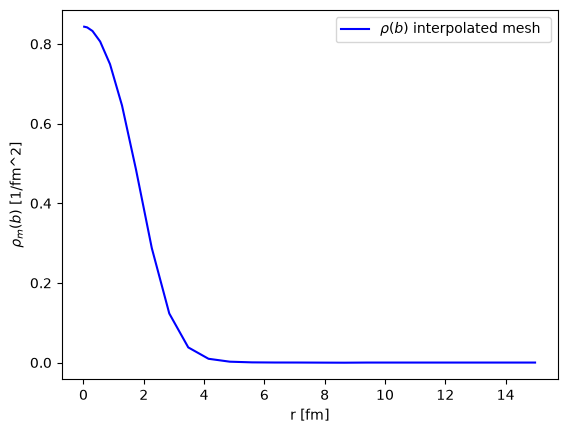

In [35]:
plt.plot(cross_section.t_mapped_roots, C_rho, color ="blue", label = r"$\rho(b)$ interpolated mesh " )
plt.ylabel(r"$\rho_m(b)$ [1/fm^2]")
plt.xlabel("r [fm]")
plt.legend()
plt.show()


The density is transformed into a density as a function of impact parameter b with a mesh consistent with the mesh in ERICCa's reaction cross section calculation function. The general way we calculate the cross section with matter densities as inputs is by calling the function in the class cross_section

    cross_section.sigma_R_matter( rho_t,  rho_p, Gamma = lambda b: np.exp(-b), Model = "OLA")

Where the inputs 
- rho_t: the matter density of the target as a function of impact parameter b in 1/fm $^2$.
- rho_p: the matter density of the projectile as a function of impact parameter b in 1/fm $^2$.
- Gamma: the profile function; the effective interaction between the target and projectile nucleus. 
- Model: the type of model used in the cross section calculation, either the "MOL" or the "OLA."

For this example we calculate the reaction cross section for 12C on 12C at 300 MeV using matter densities as inputs to cross_section.sigma_R_matter using the Optical Limit Approximation "OLA", or the Modified Optical Limit "MOL", which are two different models within the glauber framework.

(If you are interested in the differences between these models https://doi.org/10.4324/9780203168271 is a good resource)

The results can be seen below

In [36]:
print("sigma_R MOL :",np.round(cross_section.sigma_R_matter(C_rho, rho_p = C_rho, Gamma = profile_funct.Gamma , Model = "MOL")), "mb")
print("sigma_R OLA :",np.round(cross_section.sigma_R_matter(C_rho, rho_p = C_rho, Gamma = profile_funct.Gamma, Model = "OLA")), "mb") 

sigma_R MOL : 846.0 mb
sigma_R OLA : 883.0 mb


The measured value of the reaction cross section of $^{12}$ C on $^{12}$ C at 300 MeV is  860 $\pm$ 50 mb, and the calculated cross section is 846 mb, which is well within 1 sigma of our results.

 To calculate each cross section, it takes about 2 seconds.

In [37]:
%%timeit
cross_section.sigma_R_matter(C_rho, rho_p = C_rho, Gamma = profile_funct.Gamma, Model = "MOL")

2.14 s ± 60 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


This allows for fast calculations for cross section predictions.


You can also calculate the eikonal phase by calling cross_section.chi or cross_section.chi_mol()

    cross_section.chi_mol(b, rho_t, rho_p, Gamma)

where  b is the impact parameter in [fm], rho_t and rho_p are the target and projectile density [fm] and Gamma is the profile function [1/fm^2].

In [38]:
b=3
print(np.round(cross_section.chi(b, C_rho, C_rho, profile_funct.Gamma),3))
print(np.round(cross_section.chi_mol(b, C_rho,C_rho,profile_funct.Gamma),3))

(1.145+3.514j)
(0.56+2.54j)


## Calculate the Glauber model reaction cross section: proton and neutron densities

To calculate a cross section in the Glauber framework, we need the proton and neutron densities of the target and projectile densities as inputs. So the first step is to load our densities into our environment. In this example, we will calculate the $^{42}$ Ca on $^{12}$ C reaction cross section. So we will need to load $^{12}$ C and $^{42}$ Ca proton and neutron densities. I am loading in the densities calculated using the 14D Fayans energy density functions. I also included the interpolation step in this section of the tutorial since it was explained previously.

In [18]:
cross_section =ERICCa.CrossSection()

#Load in densities
C_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt",])     
C_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-prot.txt",])
C_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-neut.txt",])
C_p = np.genfromtxt(C_p_Filename[0], unpack= True)
C_r_mesh = np.genfromtxt(C_r_Filename[0], unpack= True)
C_n = np.genfromtxt(C_n_Filename[0], unpack= True)

C_rho_p = cross_section.dens_b_interpolator(C_r_mesh[0], C_p[0]) 
C_rho_n = cross_section.dens_b_interpolator(C_r_mesh[0], C_n[0])

Ca_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Ca_radius.txt",])     
Ca_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-prot.txt",])
Ca_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-neut.txt",])
Ca_p = np.genfromtxt(Ca_p_Filename[0], unpack= True)
Ca_r_mesh = np.genfromtxt(Ca_r_Filename[0], unpack= True)
Ca_n = np.genfromtxt(Ca_n_Filename[0], unpack= True)

Ca_rho_p = cross_section.dens_b_interpolator(Ca_r_mesh[0], Ca_p[0]) 
Ca_rho_n = cross_section.dens_b_interpolator(Ca_r_mesh[0], Ca_n[0])


Next to calculate the cross section. We call the function

    cross_section.sigma_R_pn(rho_t_p, rho_t_n, rho_p_p, rho_p_n, Gamma_pp, Gamma_pn, Gamma_nn , Model = "OLA")

where
- rho_t_p: the proton density of the target as a function of impact parameter b in 1/fm $^2$
- rho_t_n: the neutron density of the target as a function of impact parameter b in 1/fm $^2$
- rho_p_n: the proton density of the projectile as a function of impact parameter b in 1/fm $^2$
- rho_p_p: the proton density of the projectile as a function of impact parameter b in 1/fm $^2$
- Gamma_pp: the proton-proton profile function
- Gamma_pn: the proton-neutron profile function
- Gamma_nn : the neutron-neutron profile function
- Model: choice of model "OLA" or "MOL"


Since a reaction cross section calculated in the Glauber framework with proton and neutron densities as inputs, we need 3 profile functions for the proton-proton, proton-neutron, and neutron neutron interaction. This can be called by setting the model_type = "np" in the profile function class.

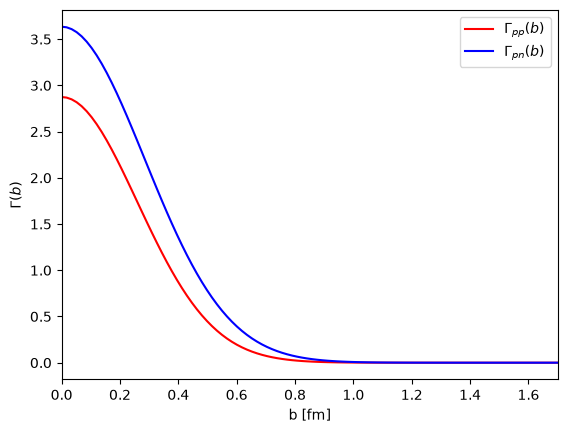

In [19]:
#An example of a programed example of a profile function
profile_funct= ERICCa.ProfileFunction(model_type = "np", E = 300)

b_mesh = np.linspace(0, 1.7, 100)
plt.plot(b_mesh, profile_funct.Gamma_pp(b_mesh).real, color = "r", label = r"$\Gamma_{pp}(b)$")
plt.plot(b_mesh, profile_funct.Gamma_pn(b_mesh).real, color = "b", label = r"$\Gamma_{pn}(b)$")
plt.xlabel("b [fm]")
plt.ylabel(r"$\Gamma(b)$")
plt.legend()
plt.xlim(0,1.7)
plt.show()

Then we plug the profile functions and the proton and neutron densities into the profile function ERICCa.sigma_R_pn to get a cross section in mb.

In [20]:
xs_pn_OLA = cross_section.sigma_R_pn(C_rho_p, C_rho_n, rho_p_p = Ca_rho_p , rho_p_n = Ca_rho_n, Gamma_pp = profile_funct.Gamma_pp, 
                   Gamma_pn = profile_funct.Gamma_pn, Gamma_nn = profile_funct.Gamma_pp , Model = "OLA")
xs_pn_MOL = cross_section.sigma_R_pn(C_rho_p, C_rho_n, rho_p_p = Ca_rho_p , rho_p_n = Ca_rho_n, Gamma_pp = profile_funct.Gamma_pp, 
                   Gamma_pn = profile_funct.Gamma_pn, Gamma_nn = profile_funct.Gamma_pp , Model = "MOL")
xs_pn_OLA_pn = cross_section.sigma_R_pn(C_rho_p, C_rho_n, rho_p_p = Ca_rho_p , rho_p_n = Ca_rho_n, Gamma_pp = profile_funct.Gamma_pp, 
                   Gamma_pn = profile_funct.Gamma_pn, Gamma_nn = profile_funct.Gamma_pp , Model = "OLA p-n")

print("Printing the p-n cross sections")
print("OLA:", np.round(xs_pn_OLA))
print("MOL:", np.round(xs_pn_MOL))
print("OLA p-n:", np.round(xs_pn_OLA_pn))

Printing the p-n cross sections
OLA: 1499.0
MOL: 1479.0
OLA p-n: 181.0


You can also calculate the eikonal phases with proton and neutron densities as inputs

In [21]:
b=3
print("chi_ola_micro:",np.round(cross_section.chi_ola_micro( b, C_rho_p, C_rho_n, Ca_rho_p , Ca_rho_n, profile_funct.Gamma_pp, 
                   profile_funct.Gamma_pn, profile_funct.Gamma_pn),3))
print("chi_mol_micro:",np.round(cross_section.chi_mol_micro( b, C_rho_p, C_rho_n, Ca_rho_p , Ca_rho_n, profile_funct.Gamma_pp, 
                   profile_funct.Gamma_pn, profile_funct.Gamma_pn),3))
print("chi_no_dens:",np.round(cross_section.chi_nN_pn(b , C_rho_p, C_rho_n, profile_funct.Gamma_pp, profile_funct.Gamma_pn),3))

chi_ola_micro: (4.155+11.023j)
chi_mol_micro: (2.503+8.769j)
chi_no_dens: (0.043+0.099j)


In [22]:
%%timeit
cross_section.sigma_R_pn(C_rho_p, C_rho_n, rho_p_p=Ca_rho_p, rho_p_n=Ca_rho_n, Gamma_pp=profile_funct.Gamma_pp, Gamma_pn=profile_funct.Gamma_pn, Gamma_nn=profile_funct.Gamma_pn, Model="OLA")

6.33 s ± 1.93 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
